# nb00 — эталон pump+dump (стартовая точка v2)

**Что это.** Это *первый запуск* новой линии `pump_dump_v2`. Он не содержит нового
исследования — он **воспроизводит итог оригинальной работы** (`notebooks/pump_dump_combined`,
ноутбуки 00–16 + `nb_best`). Дальше v2 строится поверх этого проверенного фундамента.

**Идея стратегии (в двух предложениях).** Резкие рывки цены на альтах — это в среднем
*переоценка*, которая откатывает обратно. Поэтому мы **шортим памп** (резкий рост +5% за 15 мин)
и **лонгуем дамп** (резкий провал −7% за 15 мин), ставя на возврат к среднему; а поскольку эти две
ноги теряют в *противоположных* рыночных режимах (памп-шорты — в общем ралли, дамп-лонги — в общем
крахе), вместе они дают более гладкую кривую и меньшую просадку, чем каждая по отдельности.

**Три модуля этого ноутбука** (это и есть три модуля стратегии):
1. **Сигнальный слой** — как из сырых свечей рождаются сделки (детект события → scale-in вход →
   катастроф-стоп → выход) и как классификатор отсеивает плохие входы.
2. **Портфельный движок** — как сделки превращаются в счёт: DCA-взносы, ёмкость рынка, слиппедж,
   резерв, лимит одновременных позиций.
3. **Лесенка режимов** — одна ручка риска (размер позиции), переводящая стратегию из «безопасно»
   в «агрессивно».

Все параметры унаследованы 1:1 из оригинала — провенанс каждого числа расписан в `README.md`.

## Модуль 1 — сигнальный слой (сырьё → сделки)

Сигналы уже посчитаны из сырых 1-минутных свечей (вся вселенная 173 символа, 2024-01 … 2026-07)
скриптом `_build_signals.py` и лежат в `_out/{pump,dump}_signals.parquet`. Одна строка = одно
событие (потенциальная сделка). Как строится каждое событие:

**Шаг 1. Детект события.** Идём по свечам. Памп = трейлинг-доходность за 15 мин `≥ +5%`
(+ фильтр «объём за 15 мин ≥ 3× медианы дня» — настоящий памп идёт на объёме). Дамп = за 15 мин
`≤ −7%`. Идущие подряд минуты-срабатывания склеиваются в один **кластер** (событие закрывается
после 10 «тихих» минут). Всё считается на *закрытии* бара — заглядывания в будущее нет.

**Шаг 2. Вход через scale-in (усреднение).** Не входим всем сразу на пике. Памп добирает шорт на
*каждой* минуте кластера (позднее — крупнее); дамп добирает лонг **по ценовым ступеням** — новый
транш, когда цена упала ещё на −2% от последней. Средняя цена входа `avg` — средневзвешенная.
Смысл: событие продолжается ещё какое-то время после первого триггера, и усреднение подтягивает
вход ближе к настоящей вершине/дну (это чинит lookahead-ошибку, на которой погорела ранняя памп-линия).

**Шаг 3. Катастроф-стоп.** Памп: стоп `−30%` от средней (проверяется по внутрибарному *high*, с гэп-
филлом и слиппеджем 0.1%). Дамп: `−20%` по внутрибарному *low*. Это широкий стоп «на конец света», а
не тактический — узкий стоп выбивал нас прямо перед разворотом (урок оригинала). Он почти не срабатывает
в 2024–26, но защищает в несемплированной альт-мании.

**Шаг 4. Выход.** Держим до горизонта: `конец кластера + 240 минут`. (В кэше также лежит сетка
rollover-тейков `pnl0..pnl6`; индекс **6 = hold-to-horizon** — это и есть эталон, rollover выключен.)

**Шаг 5. Классификатор (walk-forward фильтр).** По 12–14 причинным признакам на баре-триггере
(форма и скорость движения, всплеск объёма, дистанция до хай/лоу…) градиентный бустинг предсказывает
доходность сделки. Обучение на расширяющихся окнах прошлого (40→55→70→85→100%), торгуем только `pred>0`.
Первые 40% истории идут без фильтра (модели ещё нет). Классификатор — это **фильтр входа**, не сайзинг
(оригинал показал: сайзить по скору не помогает).

Код ниже загружает сигналы, применяет walk-forward-фильтр и собирает единую книгу сделок `BOOK`.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

# Кэши сигналов (см. _build_signals.py). pnl{i}/exit{i} — сетка rollover-givebacks;
# индекс 6 = hold-to-horizon = ЭТАЛОН (rollover выключен).
PUMP = pd.read_parquet("_out/pump_signals.parquet")
DUMP = pd.read_parquet("_out/dump_signals.parquet")
GIVEBACKS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, np.inf]
PUMP_G, DUMP_G = 6, 6          # hold-to-horizon

# причинные признаки на баре-триггере (для классификатора)
PF = ["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF = ["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

def naive(s):
    s = pd.to_datetime(s)
    return s.dt.tz_localize(None) if s.dt.tz is not None else s

for D in (PUMP, DUMP):
    D["entry"] = naive(D["entry"])
    for i in range(len(GIVEBACKS)):
        D[f"exit{i}"] = naive(D[f"exit{i}"])

def wf_filter(df, feats, label):
    """Walk-forward классификатор: экспандинг-окна 40/55/70/85/100%, HGBR по
    причинным фичам триггер-бара, торгуем только pred>0. Первые 40% истории —
    без фильтра (модели нет → pred=NaN)."""
    pred = np.full(len(df), np.nan)
    cuts = [int(len(df)*q) for q in (0.40, 0.55, 0.70, 0.85, 1.0)]; prev = cuts[0]
    for cut in cuts[1:]:
        tr = df.iloc[:prev]
        m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
            l2_regularization=1.0, min_samples_leaf=50, random_state=0).fit(tr[feats], tr[label])
        pred[prev:cut] = m.predict(df.iloc[prev:cut][feats]); prev = cut
    out = df.copy(); out["pred"] = pred
    return out[(pred > 0) | np.isnan(pred)]

pk = wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"]), PF, "pnl")
dk = wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"]), DF, "pnl")
BOOK = pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream","pred"]],
                  dk[["sym","entry","exit_ts","pnl","liq","stream","pred"]]]
                 ).sort_values("entry").reset_index(drop=True)

print(f"эталонная книга: {len(BOOK)} сделок  (pump {(BOOK.stream=='pump').sum()} / dump {(BOOK.stream=='dump').sum()})")
print(f"период: {BOOK.entry.min().date()} .. {BOOK.entry.max().date()}")
for s in ("pump", "dump"):
    p = BOOK[BOOK.stream == s].pnl
    print(f"  {s}: mean {p.mean()*100:+.2f}%  median {p.median()*100:+.2f}%  "
          f"win {(p>0).mean()*100:.0f}%  std {p.std()*100:.1f}%  worst {p.min()*100:.0f}%")

эталонная книга: 14509 сделок  (pump 10224 / dump 4285)
период: 2024-01-02 .. 2026-06-30
  pump: mean +0.15%  median +1.06%  win 57%  std 7.8%  worst -37%
  dump: mean +5.02%  median +4.27%  win 72%  std 14.1%  worst -38%


## Модуль 2 — портфельный движок (`run_dca`)

Книга сделок — это ещё не доходность счёта: сделки перекрываются во времени, капитал ограничен,
рынок тонкий. Движок `run_dca` проигрывает книгу как реальный счёт по времени и учитывает:

- **DCA-взносы** — старт `$1000` + `$200/мес` (донашиваем на счёт, как живой инвестор).
- **Размер позиции** — доля `f` от текущего капитала (своя для пампа и дампа — см. модуль 3).
- **Резерв** — всегда держим `10%` капитала свободным (не входим, если задействовано > 90%).
- **Лимит одновременных позиций** — `MAX=18` слотов. Если все заняты — сигнал пропускается
  (это защищает от набора коррелированной пачки в один кластерный день).
- **Ёмкость рынка** — позиция не больше `10% · (ликвидность $/мин) · 30 мин`. Микрокапы тонкие
  (~$3k/мин), поэтому крупный счёт упирается в «стену ёмкости» → это **стратегия малого счёта**.
- **Слиппедж** — спред `0.10%` + импакт, пропорциональный доле от ёмкости.
- **Учёт по NAV (unit-паи)** — чтобы взносы не создавали ложных скачков доходности; отсюда честные
  Sharpe / Sortino / maxDD и IRR (`xirr` по денежным потокам).

Один и тот же движок дал согласованные числа во всех оригинальных ноутбуках (nb07/nb15/nb16).

In [2]:
# ── движок run_dca (nb07/nb15_2, per-leg доли) ───────────────────────────────
FILL_MIN = 30; PART_CAP = 0.10; SPREAD = 0.0010; IMPACT = 0.10

def run_dca(df, ffrac=None, f_pump=0.05, f_dump=0.05, start=1000., monthly=200.,
            reserve=0.10, MAX=18, cap=True, slipmodel=True):
    en = df.entry.values.astype("datetime64[ns]"); ex = df.exit_ts.values.astype("datetime64[ns]")
    bpnl = df.pnl.values; liq = df.liq.values; stream = df.stream.values
    cap_no = PART_CAP * liq * FILL_MIN
    months = pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),
                           pd.Timestamp(ex.max()), freq="MS")
    cash = start; contrib = start; dep = 0.; units = start; openh = []; mi = 0
    nav_t = [pd.Timestamp(en.min())]; nav_v = [1.0]; cf = [(-start, pd.Timestamp(en.min()))]
    taken = 0; skipped = 0; capped = 0; slip = 0.; trec = []
    def snap(t):
        eq = cash + dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now = pd.Timestamp(en[i])
        while mi < len(months) and months[mi] <= now:
            eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
            contrib += monthly; cf.append((-monthly, months[mi])); snap(months[mi]); mi += 1
        while openh and openh[0][0] <= en[i]:
            _, no, pn, st = heapq.heappop(openh); cash += no*(1+pn); dep -= no; snap(_)
        eq = cash + dep
        f = ffrac[i] if ffrac is not None else (f_pump if stream[i] == "pump" else f_dump)
        desired = f*eq
        no = min(desired, cap_no[i]) if cap else desired
        if cap and no < desired - 1e-9: capped += 1
        if dep + no <= (1-reserve)*eq and len(openh) < MAX and cash >= no and no > 1:
            part = no/(liq[i]*FILL_MIN); sl = (SPREAD + IMPACT*part) if slipmodel else 0.0
            slip += no*sl; cash -= no; dep += no
            heapq.heappush(openh, (ex[i], no, bpnl[i]-sl, stream[i])); taken += 1
            trec.append((bpnl[i]-sl, no, stream[i])); snap(en[i])
        else:
            skipped += 1
    while mi < len(months):
        eq = cash + dep; nav = eq/units; units += monthly/nav; cash += monthly
        contrib += monthly; cf.append((-monthly, months[mi])); mi += 1
    for _, no, pn, st in sorted(openh): cash += no*(1+pn); dep -= no; snap(_)
    final = cash + dep; cf.append((final, pd.Timestamp(ex.max())))
    nav = pd.Series(nav_v, index=pd.to_datetime(nav_t)).sort_index()
    nav = nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk = pd.DataFrame(trec, columns=["pnl", "notional", "stream"]); tk["usd"] = tk.notional*tk.pnl
    return dict(final=final, contrib=contrib, nav=nav, taken=taken, skipped=skipped,
                capped=capped, slip=slip, tk=tk, cf=cf)

def xirr(cf):
    amts = np.array([a for a, _ in cf]); ds = pd.to_datetime([d for _, d in cf])
    t = np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t), -0.999, 100)
    except Exception: return np.nan

def metrics(R, tag):
    nav = R["nav"]; span = (nav.index[-1]-nav.index[0]).days/365.25
    rr = nav.pct_change().dropna(); sh = rr.mean()/rr.std()*np.sqrt(365)
    sor = rr.mean()/rr[rr < 0].std()*np.sqrt(365)
    dd = (nav.values/np.maximum.accumulate(nav.values)-1).min()
    cg = (nav.iloc[-1]/nav.iloc[0])**(1/span)-1
    tk = R["tk"]
    return dict(config=tag, final=f"${R['final']:,.0f}", mult=f"{R['final']/R['contrib']:.1f}x",
                IRR=f"{xirr(R['cf'])*100:+.0f}%", CAGR=f"{cg*100:+.0f}%", Sharpe=f"{sh:.2f}",
                Sortino=f"{sor:.2f}", maxDD=f"{dd:.1%}",
                capped=f"{R['capped']/max(R['taken'],1)*100:.0f}%",
                worst=f"{tk.pnl.min()*100:.0f}%",
                npump=int((tk.stream=='pump').sum()), ndump=int((tk.stream=='dump').sum()))

print("движок готов")

движок готов


## Модуль 3 — лесенка режимов (ручка риска)

Единственное, что меняется между режимами, — **размер позиции**. Dump везде `3%` (walk-forward
показал: дамп-ногу надо *резать*, она высоковолатильна); pump — ручка громкости `3/4/5/8%`.
Поднятие пампа = размен «рост ↔ просадка» (это лесенка одной стратегии, а не разные стратегии).
`flat 5%` (оба по 5%) — справочная строка для сравнения.

Считаем два среза:
- **Полный период** — вся история 2024–26.
- **OOS-окно** — с 40%-метки, где walk-forward-фильтр уже «живой» (обучен на прошлом). Это самая
  честная оценка.

Ниже — таблицы (это и есть «что мы имеем на данный момент») и график NAV по режимам.

In [3]:
TIERS = [("safe  pump3/dump3", 0.03, 0.03),
         ("med   pump4/dump3", 0.04, 0.03),
         ("agg   pump5/dump3", 0.05, 0.03),
         ("sagg  pump8/dump3", 0.08, 0.03),
         ("(справка) flat 5%",     0.05, 0.05)]

runs_full = {tag: run_dca(BOOK, f_pump=fp, f_dump=fd) for tag, fp, fd in TIERS}
print(f"ПОЛНЫЙ ПЕРИОД {BOOK.entry.min().date()}..{BOOK.entry.max().date()} — DCA $1000 + $200/мес, ёмкость+слиппедж:")
print(pd.DataFrame([metrics(runs_full[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))

c0 = int(len(BOOK)*0.40)
OOS = BOOK.iloc[c0:].reset_index(drop=True)
runs_oos = {tag: run_dca(OOS, f_pump=fp, f_dump=fd) for tag, fp, fd in TIERS}
print(f"\nOOS-ОКНО {OOS.entry.min().date()}..{OOS.entry.max().date()} ({len(OOS)} сделок) — там, где фильтр уже жил:")
print(pd.DataFrame([metrics(runs_oos[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))

ПОЛНЫЙ ПЕРИОД 2024-01-02..2026-06-30 — DCA $1000 + $200/мес, ёмкость+слиппедж:
           config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $32,491 4.6x +145% +141%   3.21    3.92 -13.6%    11%  -37%   8253   1927
med   pump4/dump3 $38,497 5.5x +167% +168%   3.17    3.64 -17.3%    14%  -37%   8253   1927
agg   pump5/dump3 $43,738 6.2x +184% +191%   3.04    3.34 -21.1%    16%  -37%   8250   1929
sagg  pump8/dump3 $56,997 8.1x +224% +243%   2.76    2.82 -31.5%    24%  -37%   7940   1908
(справка) flat 5% $60,743 8.7x +234% +237%   2.81    3.35 -24.8%    18%  -37%   8245   1919



OOS-ОКНО 2024-08-05..2026-06-30 (8706 сделок) — там, где фильтр уже жил:
           config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $21,389 3.8x +174% +157%   3.41    4.18 -13.0%    12%  -37%   5448   1455
med   pump4/dump3 $25,324 4.5x +207% +193%   3.45    3.88 -16.0%    15%  -37%   5448   1455
agg   pump5/dump3 $28,967 5.2x +235% +225%   3.37    3.60 -19.1%    17%  -37%   5446   1456
sagg  pump8/dump3 $37,670 6.7x +297% +301%   3.13    3.05 -29.3%    25%  -37%   5285   1441
(справка) flat 5% $39,335 7.0x +308% +284%   3.02    3.82 -22.2%    19%  -37%   5441   1451


[saved] notebooks\pump_dump_v2\_out\v2_nb00_nav.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb00_nav.png')

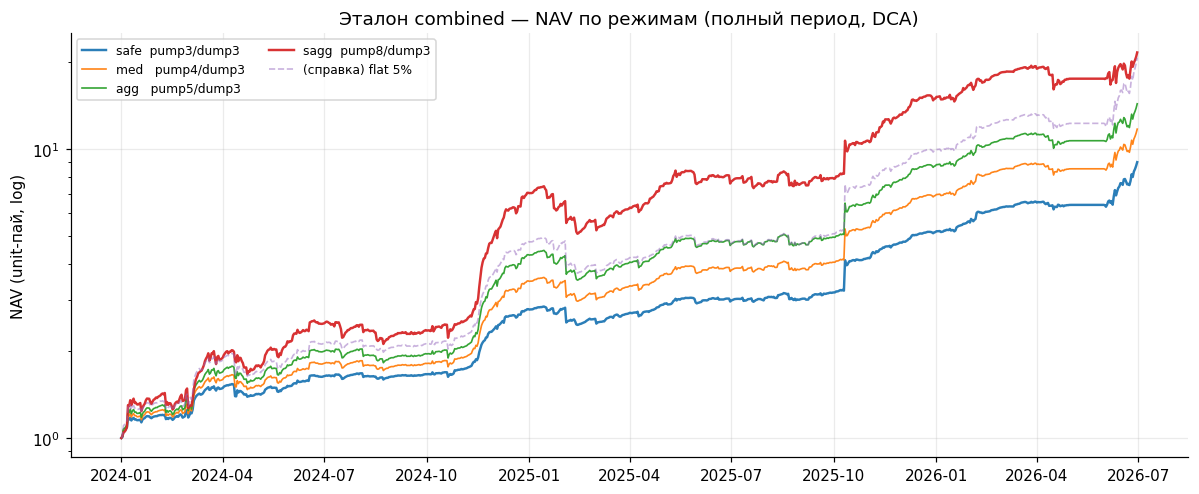

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.6))
for tag, _, _ in TIERS:
    nav = runs_full[tag]["nav"]
    ax.plot(nav.index, nav.values, label=tag, lw=1.6 if "sagg" in tag or "safe" in tag else 1.1,
            alpha=0.95 if "flat" not in tag else 0.5,
            ls="--" if "flat" in tag else "-")
ax.set_yscale("log"); ax.set_ylabel("NAV (unit-пай, log)"); ax.set_title("Эталон combined — NAV по режимам (полный период, DCA)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25)
show("v2_nb00_nav")

## Прогон БЕЗ классификатора + разбор памп-ноги

Два вопроса пользователя:
1. **Что даёт классификатор?** Прогоним ту же лесенку, но с *выключенным* WF-фильтром — торгуем
   ВСЕ события пампа и дампа (`BOOK_ALL`), и сравним с отфильтрованным эталоном.
2. **Почему памп per-trade приносит так мало** (mean всего +0.15%), если в боте памп-нога — самая
   доходная? Разберём это тремя измерениями: распределение сделки, частота, роль хеджа.

In [5]:
# ── книга БЕЗ фильтра (торгуем все сигналы) ──────────────────────────────────
cols = ["sym","entry","exit_ts","pnl","liq","stream"]
pa = PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"], exit_ts=PUMP[f"exit{PUMP_G}"])
da = DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"], exit_ts=DUMP[f"exit{DUMP_G}"])
BOOK_ALL = pd.concat([pa[cols], da[cols]]).sort_values("entry").reset_index(drop=True)
print(f"книга БЕЗ фильтра: {len(BOOK_ALL)} сделок  (pump {(BOOK_ALL.stream=='pump').sum()} / "
      f"dump {(BOOK_ALL.stream=='dump').sum()})   vs эталон с фильтром: {len(BOOK)}")

print("\nэффект фильтра на per-trade (эталон=pred>0  vs  all=торгуем всё):")
for s in ("pump","dump"):
    f = BOOK[BOOK.stream==s].pnl; a = BOOK_ALL[BOOK_ALL.stream==s].pnl
    print(f"  {s}: фильтр mean {f.mean()*100:+.2f}% median {f.median()*100:+.2f}% win {(f>0).mean()*100:.0f}% n={len(f)}"
          f"   |   all mean {a.mean()*100:+.2f}% median {a.median()*100:+.2f}% win {(a>0).mean()*100:.0f}% n={len(a)}")

runs_all = {tag: run_dca(BOOK_ALL, f_pump=fp, f_dump=fd) for tag, fp, fd in TIERS}
print(f"\nБЕЗ КЛАССИФИКАТОРА — полный период, та же DCA-машинерия:")
print(pd.DataFrame([metrics(runs_all[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))
print(f"\n(для сравнения — С классификатором, полный период:)")
print(pd.DataFrame([metrics(runs_full[tag], tag) for tag, _, _ in TIERS]).to_string(index=False))

книга БЕЗ фильтра: 18240 сделок  (pump 13145 / dump 5095)   vs эталон с фильтром: 14509

эффект фильтра на per-trade (эталон=pred>0  vs  all=торгуем всё):
  pump: фильтр mean +0.15% median +1.06% win 57% n=10224   |   all mean -0.14% median +0.54% win 54% n=13145
  dump: фильтр mean +5.02% median +4.27% win 72% n=4285   |   all mean +4.51% median +3.78% win 68% n=5095



БЕЗ КЛАССИФИКАТОРА — полный период, та же DCA-машинерия:
           config   final  mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $38,299  5.5x +166% +162%   3.34    3.73 -11.5%    13%  -39%   9673   2540
med   pump4/dump3 $47,016  6.7x +195% +195%   3.24    3.40 -13.4%    16%  -39%   9673   2540
agg   pump5/dump3 $54,974  7.9x +218% +224%   3.06    3.13 -15.7%    19%  -40%   9665   2543
sagg  pump8/dump3 $80,530 11.5x +283% +302%   2.74    2.86 -25.1%    29%  -40%   9260   2521
(справка) flat 5% $74,633 10.7x +269% +273%   2.92    3.20 -20.4%    21%  -40%   9660   2527

(для сравнения — С классификатором, полный период:)
           config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
safe  pump3/dump3 $32,491 4.6x +145% +141%   3.21    3.92 -13.6%    11%  -37%   8253   1927
med   pump4/dump3 $38,497 5.5x +167% +168%   3.17    3.64 -17.3%    14%  -37%   8253   1927
agg   pump5/dump3 $43,738 6.2x +184% +191%   3.04    3.

### Разбор: почему памп per-trade мал, но в портфеле/боте тащит

Смотрим не на среднее (оно обманчиво из-за хвоста), а на всю картину: распределение сделки,
частоту событий и **роль хеджа** (прогон каждой ноги отдельно через тот же движок).

In [6]:
# (1) распределение сделки: среднее топит хвост, но медиана и win — в плюсе
print("(1) РАСПРЕДЕЛЕНИЕ сделки (эталон, hold-to-horizon):")
for s in ("pump","dump"):
    p = BOOK[BOOK.stream==s].pnl
    print(f"  {s}: mean {p.mean()*100:+.2f}%  median {p.median()*100:+.2f}%  win {(p>0).mean()*100:.0f}%  "
          f"std {p.std()*100:.1f}%  q10 {p.quantile(.10)*100:+.1f}%  worst {p.min()*100:.0f}%  n={len(p)}")
print("  -> памп: медиана ПЛЮС (+1%), win 57% (большинство сделок в плюс), но жирный левый хвост")
print("     (раннеры до -37%) топит СРЕДНЕЕ к нулю. При сайзинге 3-8% хвост размывается, а")
print("     плюсовая медиана компаундится -> нога зарабатывает В ПОРТФЕЛЕ, не в 'mean'.")

# (2) частота: пампов кратно больше -> больше сделок в книге
npu, ndu = (BOOK.stream=="pump").sum(), (BOOK.stream=="dump").sum()
print(f"\n(2) ЧАСТОТА: pump {npu} vs dump {ndu} событий  ->  пампов в {npu/ndu:.1f}x больше.")

# (3) роль ХЕДЖА: каждая нога отдельно vs combined (agg-сайз) через тот же движок
Rp = run_dca(BOOK[BOOK.stream=="pump"].reset_index(drop=True), f_pump=0.05, f_dump=0.05)
Rd = run_dca(BOOK[BOOK.stream=="dump"].reset_index(drop=True), f_pump=0.03, f_dump=0.03)
Rc = run_dca(BOOK, f_pump=0.05, f_dump=0.03)
print("\n(3) КАЖДАЯ НОГА ОТДЕЛЬНО vs COMBINED (тот же движок, agg pump5/dump3):")
print(pd.DataFrame([metrics(Rp,"pump-only 5%"), metrics(Rd,"dump-only 3%"),
                    metrics(Rc,"combined 5/3")]).to_string(index=False))

# вклад каждой ноги в COMBINED (валовый реализованный $ и число сделок)
g = Rc["tk"].groupby("stream").agg(gross_usd=("usd","sum"), n=("usd","size"), avg_notional=("notional","mean"))
print("\nвклад каждой ноги в COMBINED (валовый $ и сделки):")
print(g.to_string())
print("\n-> combined Sharpe ВЫШE каждой ноги в одиночку = диверсификация (корр ~-0.5).")
print("   Памп-нога и по валовому $, и по числу сделок — крупный вклад, хотя её 'mean' почти ноль.")

(1) РАСПРЕДЕЛЕНИЕ сделки (эталон, hold-to-horizon):
  pump: mean +0.15%  median +1.06%  win 57%  std 7.8%  q10 -8.4%  worst -37%  n=10224
  dump: mean +5.02%  median +4.27%  win 72%  std 14.1%  q10 -6.0%  worst -38%  n=4285
  -> памп: медиана ПЛЮС (+1%), win 57% (большинство сделок в плюс), но жирный левый хвост
     (раннеры до -37%) топит СРЕДНЕЕ к нулю. При сайзинге 3-8% хвост размывается, а
     плюсовая медиана компаундится -> нога зарабатывает В ПОРТФЕЛЕ, не в 'mean'.

(2) ЧАСТОТА: pump 10224 vs dump 4285 событий  ->  пампов в 2.4x больше.



(3) КАЖДАЯ НОГА ОТДЕЛЬНО vs COMBINED (тот же движок, agg pump5/dump3):
      config   final mult   IRR  CAGR Sharpe Sortino  maxDD capped worst  npump  ndump
pump-only 5% $20,167 2.9x  +90%  +99%   2.29    2.11 -21.8%    14%  -37%   8528      0
dump-only 3% $14,125 2.0x  +55%  +43%   1.62    2.00 -12.9%    10%  -32%      0   2025
combined 5/3 $43,738 6.2x +184% +191%   3.04    3.34 -21.1%    16%  -37%   8250   1929

вклад каждой ноги в COMBINED (валовый $ и сделки):
           gross_usd     n  avg_notional
stream                                  
dump    19960.093860  1929    471.575838
pump    16777.971651  8250    490.533661

-> combined Sharpe ВЫШE каждой ноги в одиночку = диверсификация (корр ~-0.5).
   Памп-нога и по валовому $, и по числу сделок — крупный вклад, хотя её 'mean' почти ноль.


### Ответ на вопрос про памп-ногу

- **«Mean +0.15%» вводит в заблуждение.** У пампа медиана **+1%** и win **57%** — большинство
  сделок в плюс. Среднее к нулю топит жирный левый хвост (раннеры до −37%). При сайзинге 3–8% этот
  хвост размывается (−37% × малый размер), а плюсовая медиана компаундится → **нога зарабатывает в
  портфеле, а не в per-trade mean**.
- **Частота.** Пампов кратно больше, чем дампов (~2.4×) → в книге сильно больше памп-сделок. Много
  мелких плюсов × компаундинг = заметный вклад.
- **Сайзинг.** В боевых режимах памп сайзят крупнее (5–8%) дампа (3%) → на памп идёт больше капитала.
- **Хедж.** Combined Sharpe выше любой ноги в одиночку — это корреляция −0.5. Памп ценен даже с
  нулевым средним: он гасит просадки дампа (и наоборот). Убери памп → Sharpe combined рушится.
- **Бот vs ноутбук.** Бот входит по **триггер-close** (≈ на ~0.5pp/сделку лучше нашего next-bar входа —
  фейд фронт-загружен в первую минуту), а в одном окне (29.06–03.07) памп-фильтр был технически мёртв
  → бот торговал памп вообще без фильтра. На короткой live-выборке это легко делает памп «самой
  доходной» — но это шум малой выборки + лучший вход, не признак что честный per-trade edge пампа велик.

**Вывод честный (как в оригинале nb08/09):** raw per-trade edge пампа тонкий; его ценность —
**частота + плюсовая медиана + роль хеджа**, а не большое среднее. То, что в боте памп «самый
доходный», объясняется частотой, крупным сайзингом, входом по триггер-close и (в одном окне)
отсутствием фильтра — а не тем, что памп сам по себе сильный edge.

## Что мы имеем на данный момент (итог оригинала)

**Что выжило после честного аудита (оригинал nb08/09/15/16):**
- **Дамп-нога — настоящий edge.** Лонг отскока после провала −7%/15м робастен на 3 периодах,
  ~+5%/сделку, стоп не нужен, усреднение помогает.
- **Памп-нога — прежде всего ХЕДЖ.** Её raw-edge тонкий (легендарный «Sharpe 7» был фикцией
  модели стопа — рефутировано в nb08/09). Но корреляция ног ≈ **−0.5**: без пампа Sharpe combined
  рушится с ~3 до ~1.35. Памп-фейд держим без тактического стопа (только катастроф −30%) +
  классификатор + малый размер.
- **Диверсификация реальна** (corr −0.5): combined ≫ суммы ног, кривая глаже.
- **Стратегия малого счёта.** Из-за стены ёмкости CAGR схлопывается с ростом капитала
  ($1k → большая доходность, $1M → почти ноль). Большой множитель в DCA = компаундинг × перемножение
  ног × малый счёт, а не сверх-edge.
- **Размер = ручка риска.** Dump резать до ~3%; pump — рост↔просадка, Sharpe-сладкая точка ~5%.
- **Хвост.** worst-трейд ~−37% при любом сайзинге (гэповый хвост дампа — работа стопа); настоящей
  альт-мании в выборке не было → страховки (катастроф-стоп, kill-switch) in-sample почти бесплатны,
  но их выплата — в несемплированном крахе.
- **nb16 (важно):** старый движок завышал за счёт нахлёста позиций на одном символе; честная модель —
  **одна позиция на символ** → терминал агрессивного режима ~вдвое ниже, зато Sharpe выравнивается и
  maxDD чинится. Живой бот и так режет до одной позиции на символ.

**Оговорки (что НЕ смоделировано):** тонкий памп-классификатор, entry-слиппедж на дне краха,
несемплированный хвост мании, live=0 (только paper-бот). Числа — **in-sample потолок**, не прогноз.

**Куда дальше в v2** (предложения — выбираешь ты):
1. Перенести «одна позиция на символ» (nb16) прямо в движок как дефолт — честная база v2.
2. Сблизить эталон с боевым ботом (из сверки nb_best): volume-база 240→1440м, кулдаун от закрытия /
   запрет перезахода в активный дамп, scale-in по всему кластеру.
3. Устойчивость памп-классификатора (anti-overfit, больше признаков / порядок потока).
4. Kill-switch на мелт-ап как причинный фильтр пампа.
5. Graduation в `strategies/` + живой малый paper-бот с дефолтными хвост-лимитами.